Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

Create Dataset

In [7]:
np.random.seed(42)

data = {
    'Post_ID': range(1, 201),
    'Likes': np.random.randint(50, 500, 200),
    'Comments': np.random.randint(10, 100, 200),
    'Shares': np.random.randint(5, 50, 200),
    'Post_Type': np.random.choice(['Image', 'Video', 'Text'], 200),
    'Date': pd.date_range(start='2023-01-01', periods=200)
}

df = pd.DataFrame(data)

df.to_csv('../data/social_media.csv', index=False)

df.head()

,Post_ID,Likes,Comments,Shares,Post_Type,Date
0,1,152,53,29,Image,2023-01-01
1,2,485,93,28,Video,2023-01-02
2,3,398,39,17,Video,2023-01-03
3,4,320,71,11,Text,2023-01-04
4,5,156,84,40,Video,2023-01-05


Load Dataset

In [8]:
df = pd.read_csv('../data/social_media.csv')

print("Shape:", df.shape)
df.head()

Shape: (200, 6)


,Post_ID,Likes,Comments,Shares,Post_Type,Date
0,1,152,53,29,Image,2023-01-01
1,2,485,93,28,Video,2023-01-02
2,3,398,39,17,Video,2023-01-03
3,4,320,71,11,Text,2023-01-04
4,5,156,84,40,Video,2023-01-05


Data Cleaning & Feature Engineering

In [9]:
# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# Create Engagement column
df['Engagement'] = df['Likes'] + df['Comments'] + df['Shares']

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df.fillna(0, inplace=True)

Basic Metrics

In [10]:
print("Total Posts:", len(df))
print("Average Engagement:", df['Engagement'].mean())

Total Posts: 200
Average Engagement: 350.08


Engagement by Content Type

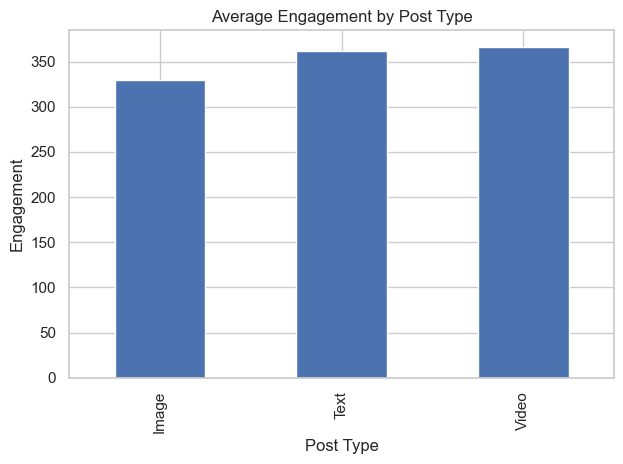

In [11]:
content_perf = df.groupby('Post_Type')['Engagement'].mean()

content_perf.plot(kind='bar')

plt.title("Average Engagement by Post Type")
plt.xlabel("Post Type")
plt.ylabel("Engagement")

plt.tight_layout()
plt.savefig('../visualizations/content_performance.png')
plt.show()

Engagement Trend Over Time

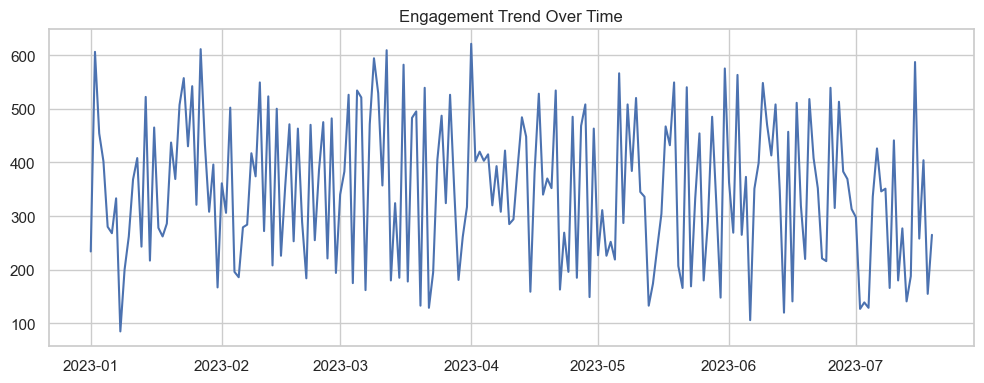

In [12]:
df.set_index('Date', inplace=True)

plt.figure(figsize=(10,4))

plt.plot(df['Engagement'])

plt.title("Engagement Trend Over Time")

plt.tight_layout()
plt.savefig('../visualizations/engagement_trend.png')
plt.show()

Likes vs Comments

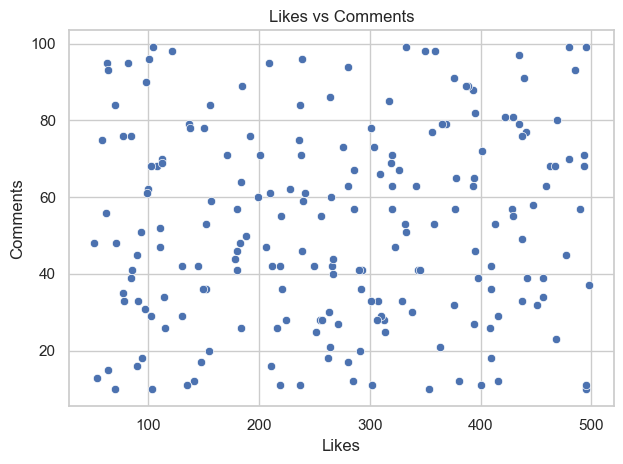

In [13]:
sns.scatterplot(x='Likes', y='Comments', data=df)

plt.title("Likes vs Comments")

plt.tight_layout()
plt.savefig('../visualizations/likes_vs_comments.png')
plt.show()

Correlation

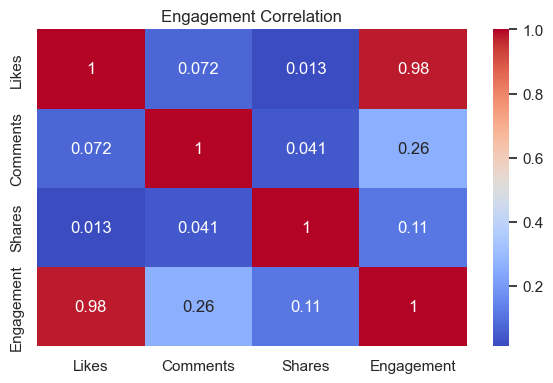

In [14]:
corr = df[['Likes','Comments','Shares','Engagement']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Engagement Correlation")

plt.tight_layout()
plt.savefig('../visualizations/social_corr.png')
plt.show()

Top Performing Posts

In [15]:
top_posts = df.sort_values(by='Engagement', ascending=False).head(10)

top_posts

,Post_ID,Likes,Comments,Shares,Post_Type,Engagement
Date,,,,,,
2023-04-01,91,495,99,27,Video,621
2023-01-27,27,493,71,47,Video,611
2023-03-12,71,480,99,30,Text,609
2023-01-02,2,485,93,28,Video,606
2023-03-09,68,493,68,33,Image,594
2023-07-15,196,490,57,40,Video,587
2023-03-16,75,469,80,33,Video,582
2023-05-31,151,498,37,40,Text,575
2023-05-06,126,441,77,48,Text,566


Save Report

In [16]:
df.to_csv('../reports/social_media_analysis.pdf')

FINAL INSIGHTS:

1. Video posts generate the highest engagement.
2. Engagement shows fluctuations over time.
3. Likes and comments are strongly correlated.
4. High engagement posts typically have more shares.
5. Certain post types consistently perform better.

RECOMMENDATIONS:

1. Focus on high-performing content types.
2. Increase posting frequency during peak engagement periods.
3. Encourage audience interaction to boost engagement.
4. Optimize content strategy based on performance trends.